In [86]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_model

In [87]:
model_path = '/content/drive/MyDrive/Walmart_sales_forecasting/artifacts/model/sales_forecast_model.pkl'

model = load_model(model_path)

model

LGBMRegressor(bagging_fraction=0.9348036408197478, bagging_freq=6,
              feature_fraction=0.7184781423801022,
              learning_rate=0.09645961410588376, metric='rmse',
              min_child_samples=6, num_leaves=50, objective='regression',
              verbose=-1)

In [88]:
%cd /content/Walmart_sales_forecasting/
df_path = 'data/processed/feature_engineering.feather'
df_feature = pd.read_feather(df_path)
df_feature

/content/Walmart_sales_forecasting


,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,mean_sales_last_52_week,max_sales_last_52_week,min_sales_last_52_week,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,1,1,2010-03-19,22136.64,151315,54.58,2.720,0.00,0.00,0.0,...,20183.157115,124418.65,-698.00,29776.749143,35820.081568,20227.707859,1472515.79,20451.608194,846686.47,18815.254889
149,1,2,2010-03-19,43615.49,151315,54.58,2.720,0.00,0.00,0.0,...,20273.734231,124418.65,-698.00,29775.363319,28978.360784,21659.406965,1472515.79,20451.608194,1848039.78,41067.550667
292,1,3,2010-03-19,9001.37,151315,54.58,2.720,0.00,0.00,0.0,...,21008.705962,124418.65,-698.00,29872.478944,36296.925392,38126.469241,1472515.79,20451.608194,371295.10,8251.002222
435,1,4,2010-03-19,34118.11,151315,54.58,2.720,0.00,0.00,0.0,...,20975.929423,124418.65,-698.00,29884.937600,22649.147696,16282.644810,1472515.79,20451.608194,1064848.12,23663.291556
578,1,5,2010-03-19,22632.57,151315,54.58,2.720,0.00,0.00,0.0,...,21480.558462,124418.65,-698.00,29880.969049,28383.628848,29659.243703,1472515.79,20451.608194,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,118221,58.85,3.882,4018.91,58.08,100.0,...,9460.779808,54608.75,23.92,12025.307089,35354.118359,45312.322469,760281.43,11347.484030,1049693.34,24992.698571
421146,45,94,2012-10-26,5203.31,118221,58.85,3.882,4018.91,58.08,100.0,...,9309.340577,54608.75,23.92,12063.252477,18920.959180,13193.930617,760281.43,11347.484030,1291378.41,29349.509318
421289,45,95,2012-10-26,56017.47,118221,58.85,3.882,4018.91,58.08,100.0,...,9336.483462,54608.75,23.92,12052.177317,12062.134590,7200.965154,760281.43,11347.484030,3002617.27,66724.828222
421434,45,97,2012-10-26,6817.48,118221,58.85,3.882,4018.91,58.08,100.0,...,9909.124423,56017.47,23.92,13492.432928,34039.802295,43813.343789,760281.43,11347.484030,596563.70,13558.265909


In [89]:
cols_to_drop = ['Date', 'store_dept', 'Weekly_Sales', 'is_test'] # do not drop dept and store column so that model can learn unique pattern of specific ones

X_train = df_feature[~df_feature['is_test']].drop(cols_to_drop, axis=1)
y_train = df_feature[~df_feature['is_test']]['Weekly_Sales']

X_test = df_feature[df_feature['is_test']].drop(cols_to_drop, axis=1)
y_test = df_feature[df_feature['is_test']]['Weekly_Sales']

X_train


,Store,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,mean_sales_last_52_week,max_sales_last_52_week,min_sales_last_52_week,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,1,1,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,20183.157115,124418.65,-698.00,29776.749143,35820.081568,20227.707859,1472515.79,20451.608194,846686.47,18815.254889
149,1,2,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,20273.734231,124418.65,-698.00,29775.363319,28978.360784,21659.406965,1472515.79,20451.608194,1848039.78,41067.550667
292,1,3,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,21008.705962,124418.65,-698.00,29872.478944,36296.925392,38126.469241,1472515.79,20451.608194,371295.10,8251.002222
435,1,4,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,20975.929423,124418.65,-698.00,29884.937600,22649.147696,16282.644810,1472515.79,20451.608194,1064848.12,23663.291556
578,1,5,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,...,21480.558462,124418.65,-698.00,29880.969049,28383.628848,29659.243703,1472515.79,20451.608194,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421000,45,93,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,9023.586346,55100.78,-1.91,11959.182352,31767.816389,40144.232916,725729.51,10517.818986,1177581.75,28037.660714
421134,45,94,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,8559.113462,55100.78,-1.91,11687.992754,17626.748194,12650.318229,725729.51,10517.818986,1410974.73,35274.368250
421277,45,95,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,8435.615577,55100.78,-1.91,11696.696569,11052.484097,6521.244557,725729.51,10517.818986,3411164.17,75803.648222
421422,45,97,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,...,9126.529615,55100.78,-1.91,13181.244801,32005.307049,41348.908639,725729.51,10517.818986,671580.72,15263.198182


# **Prediction**

In [90]:
test_df = df_feature[df_feature['is_test']].copy()
test_df['pred'] = model.predict(X_test)
test_df['error'] = test_df['Weekly_Sales'] - test_df['pred']
test_df['abs_error'] = np.abs(test_df['Weekly_Sales'] - test_df['pred'])

test_df


,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,std_sales_last_52_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week,pred,error,abs_error
131,1,1,2012-08-10,16119.92,151315,85.05,3.494,11436.22,245.00,6.85,...,33463.734596,16256.367767,4649.132189,1592409.97,22116.805139,645714.28,14349.206222,15930.719591,189.200409,189.200409
274,1,2,2012-08-10,46729.91,151315,85.05,3.494,11436.22,245.00,6.85,...,33401.532337,16188.143884,13252.223047,1592409.97,22116.805139,2068667.10,45970.380000,45953.168636,776.741364,776.741364
417,1,3,2012-08-10,28257.30,151315,85.05,3.494,11436.22,245.00,6.85,...,33555.099995,31459.026942,38360.488262,1592409.97,22116.805139,1286478.13,28588.402889,34754.174548,-6496.874548,6496.874548
560,1,4,2012-08-10,40343.83,151315,85.05,3.494,11436.22,245.00,6.85,...,33482.905713,29858.163471,30783.097065,1592409.97,22116.805139,1250046.56,27778.812444,38302.686635,2041.143365,2041.143365
703,1,5,2012-08-10,18232.46,151315,85.05,3.494,11436.22,245.00,6.85,...,33491.269590,35100.996735,37953.646766,1592409.97,22116.805139,636480.17,14144.003778,17457.805392,774.654608,774.654608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,118221,58.85,3.882,4018.91,58.08,100.00,...,12025.307089,35354.118359,45312.322469,760281.43,11347.484030,1049693.34,24992.698571,2433.087980,54.712020,54.712020
421146,45,94,2012-10-26,5203.31,118221,58.85,3.882,4018.91,58.08,100.00,...,12063.252477,18920.959180,13193.930617,760281.43,11347.484030,1291378.41,29349.509318,4079.136692,1124.173308,1124.173308
421289,45,95,2012-10-26,56017.47,118221,58.85,3.882,4018.91,58.08,100.00,...,12052.177317,12062.134590,7200.965154,760281.43,11347.484030,3002617.27,66724.828222,49666.772136,6350.697864,6350.697864
421434,45,97,2012-10-26,6817.48,118221,58.85,3.882,4018.91,58.08,100.00,...,13492.432928,34039.802295,43813.343789,760281.43,11347.484030,596563.70,13558.265909,5951.039615,866.440385,866.440385


<Figure size 1200x300 with 0 Axes>

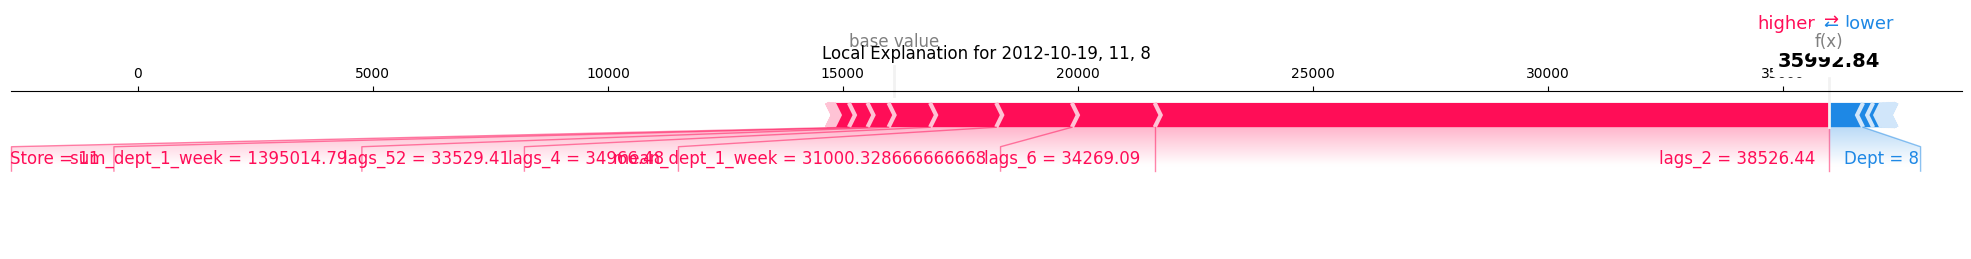

<Figure size 1200x300 with 0 Axes>

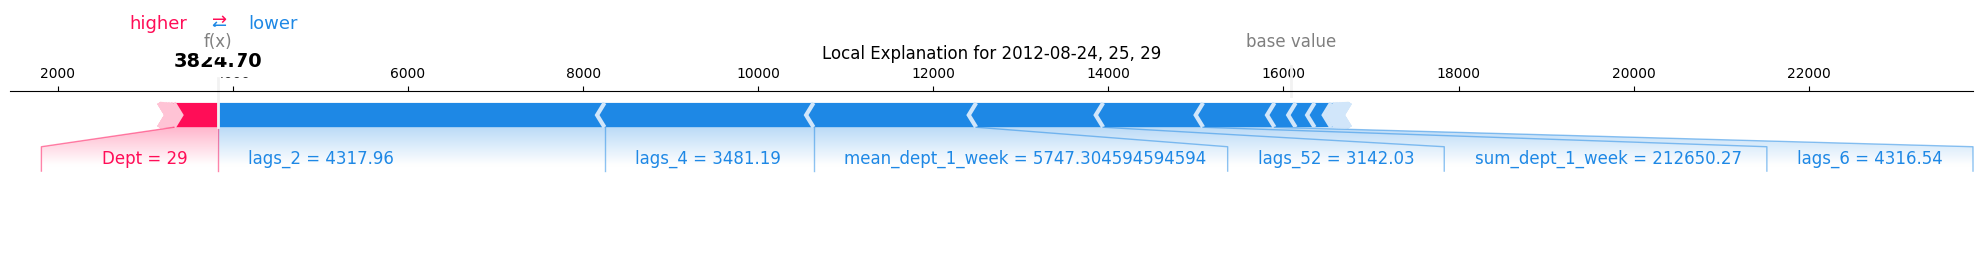

<Figure size 1200x300 with 0 Axes>

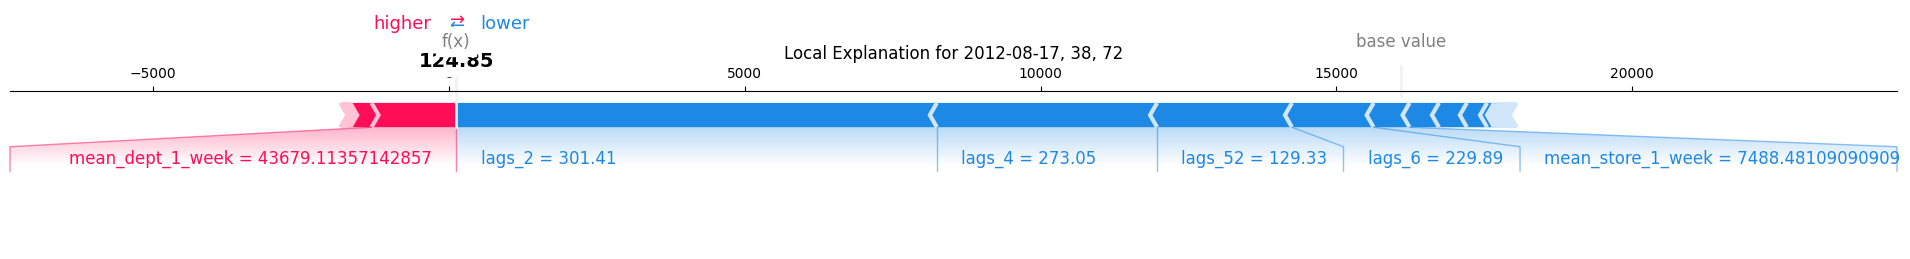

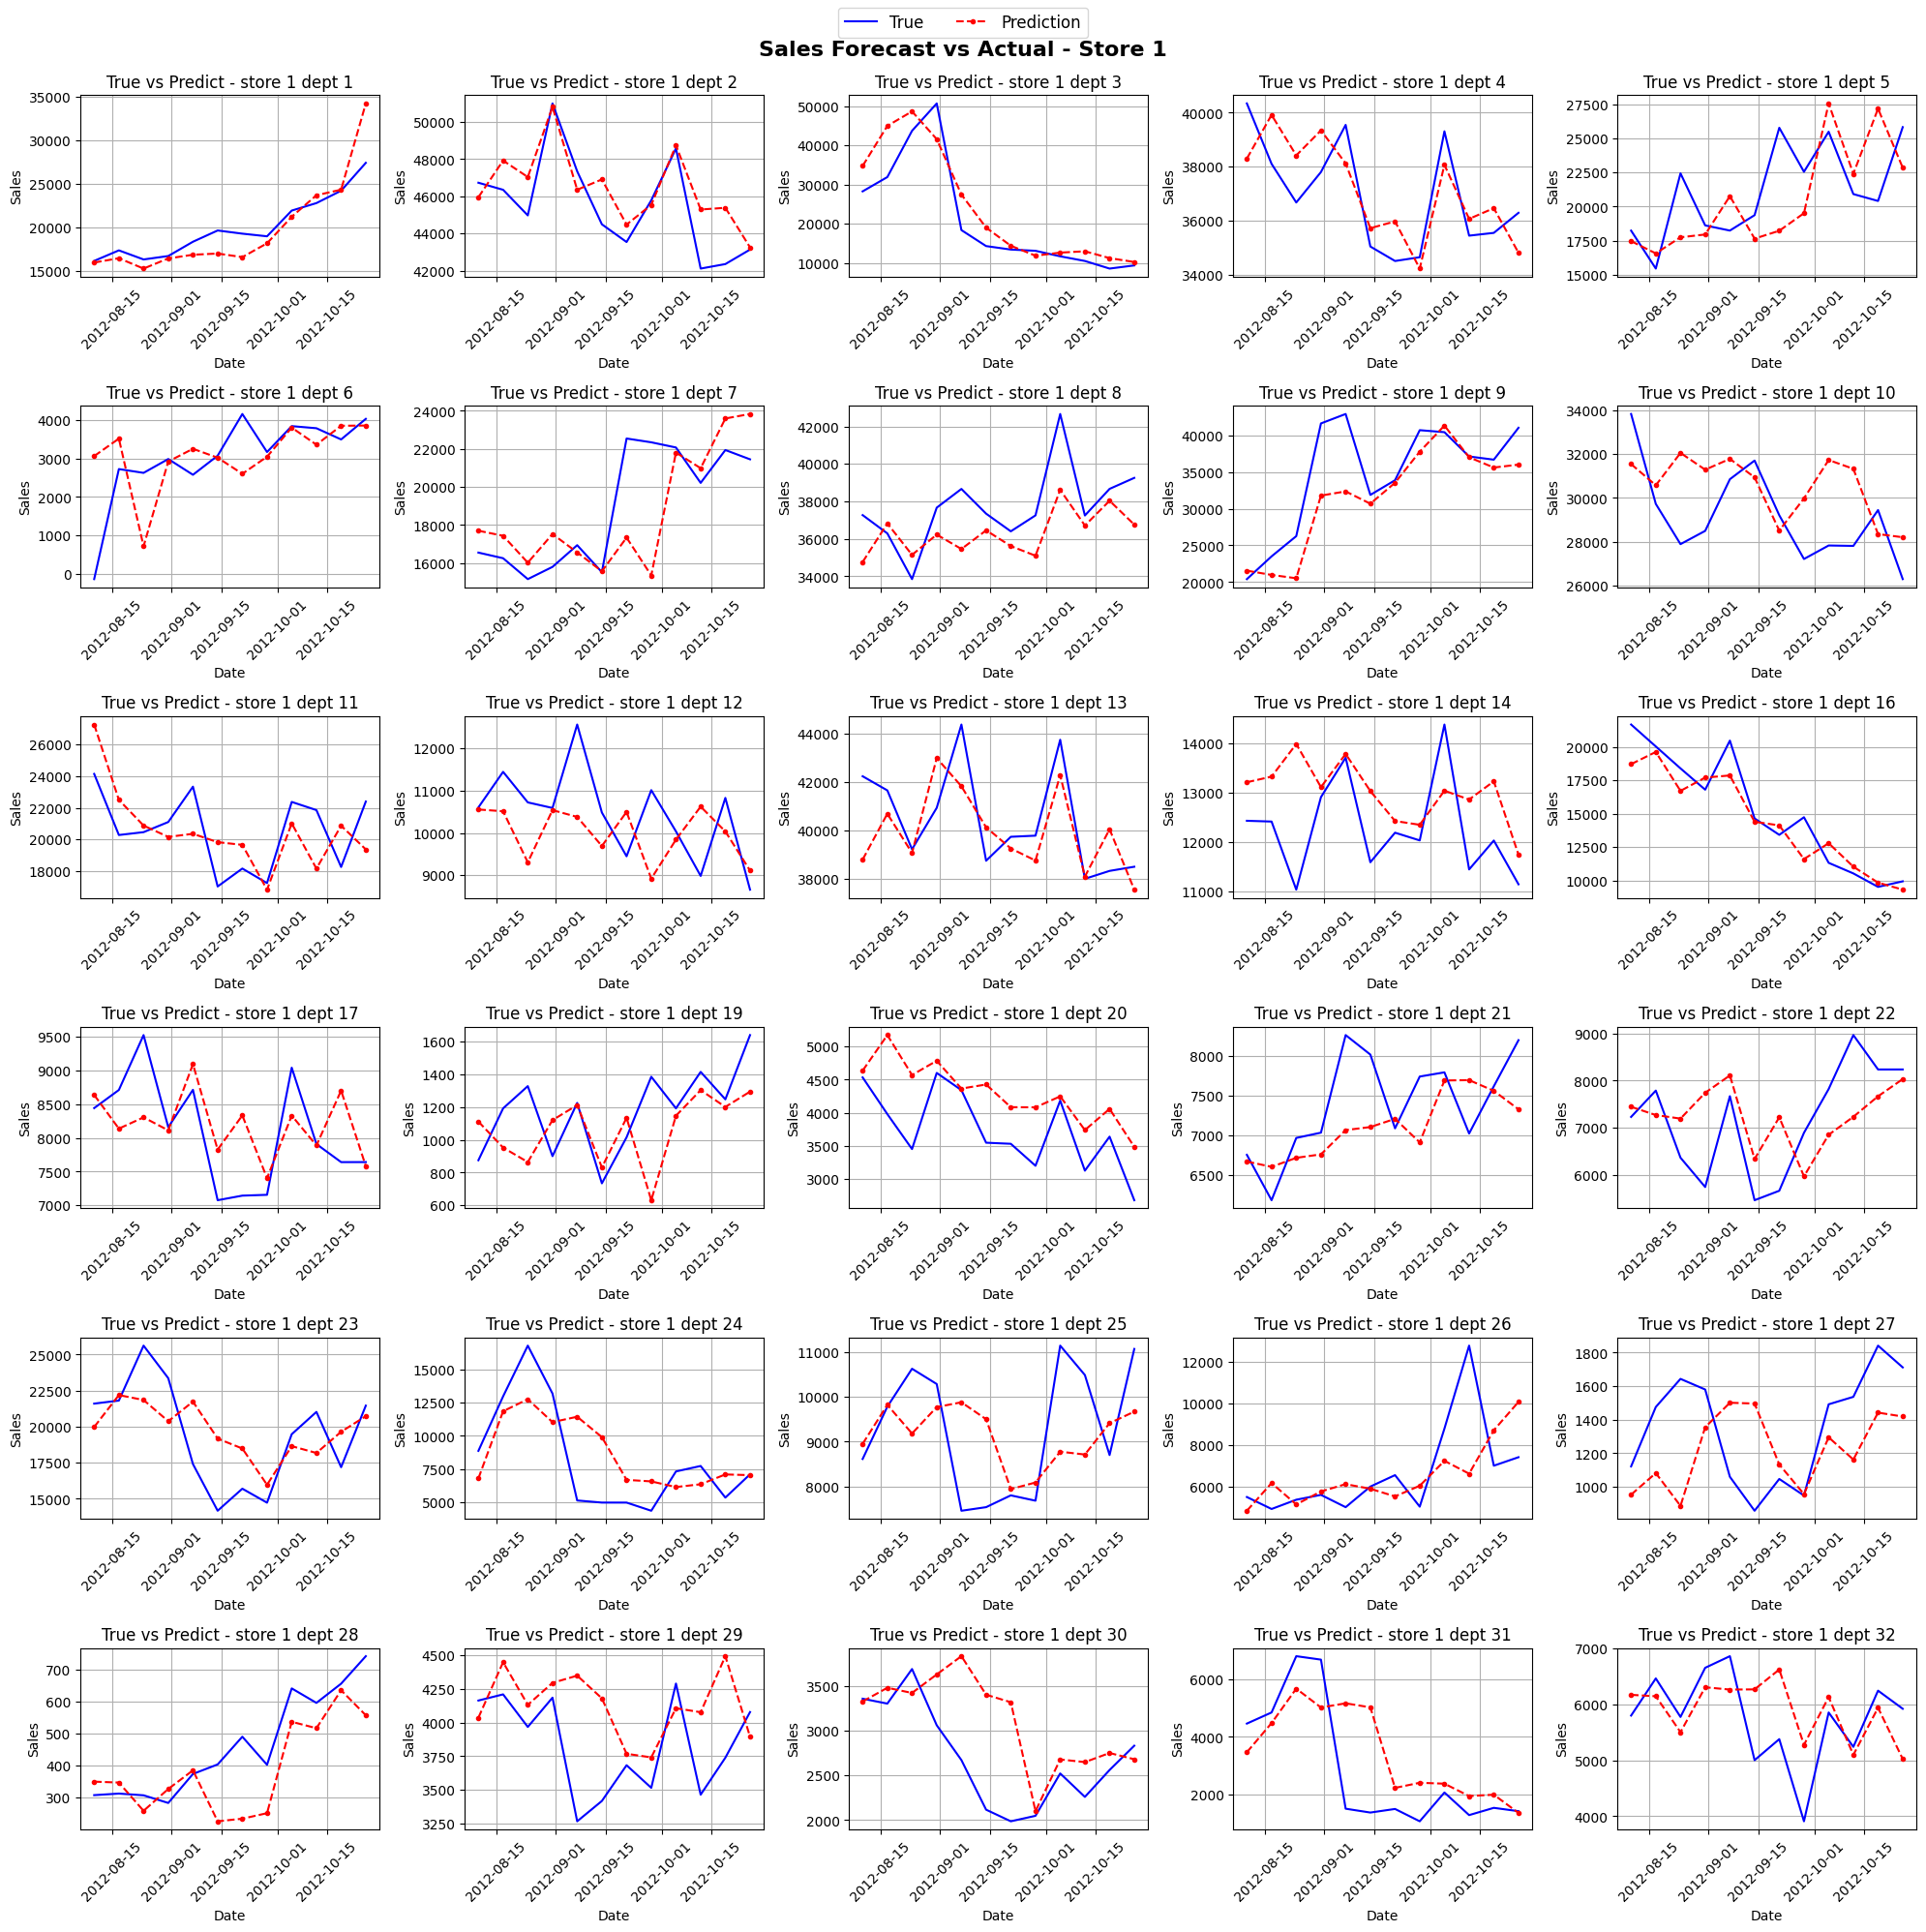

In [91]:
from src.plots import plot_sales_prediction
df_predict = test_df[['Store', 'Dept', 'Date', 'Weekly_Sales', 'pred']]
plot_sales_prediction(df_predict)

# **xAI - SHAP**

In [92]:
import shap

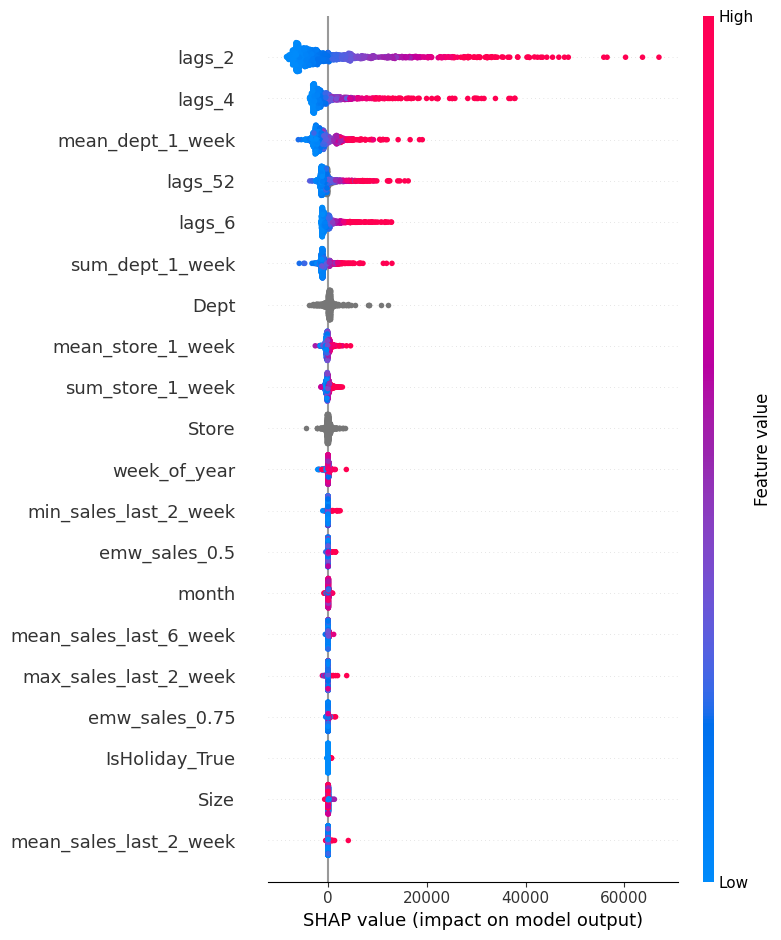

In [93]:
X_train_sample = X_train.sample(min(500, len(X_train)), random_state=42) 
X_test_sample = X_test.sample(min(500, len(X_test)), random_state=42) 

sample = pd.concat([X_train_sample, X_test_sample])
explainer = shap.TreeExplainer(model)
shap_val = explainer.shap_values(sample)

shap.summary_plot(shap_val, sample)


# SHAP Feature Importance Analysis

The illustration shows a **SHAP feature importance summary** – a visualization of how much each feature contributes to the model's predictions.

---

## Key Insights from the Illustration

### Top Features Driving Predictions:

| Rank | Feature Name | SHAP Value | Interpretation |
|------|--------------|------------|----------------|
| 1 | **`lags_2`** | 300,000 | **Strongest impact** – sales from 2 weeks ago dominate predictions |
| 2 | **`lags_4`** | 250,000 | Sales from 4 weeks ago – very strong influence |
| 3 | **`mean_dept_1-week`** | 200,000 | Department-level average sales have strong impact |
| 4 | **`lags_5`** | 180,000 | Sales from 5 weeks ago – significant contribution |
| 5 | **`lags_6`** | 150,000 | 6-week lag – moderate impact |
| 6 | **`sum_dept_1-week`** | 120,000 | Department total sales – notable influence |
| 7 | **`Dept`** | 100,000 | Department ID – important categorical feature |
| 8 | **`mean_store_1-week`** | 80,000 | Store-level average sales – meaningful |
| 9 | **`sum_store_1-week`** | 70,000 | Store total sales – contributes |
| 10 | **`Store`** | 60,000 | Store ID – contributes |
| 11 | **`week_of_year`** | 50,000 | Seasonal weekly patterns – moderate |
| 12 | **`min_sales_last_2-week`** | 40,000 | Rolling minimum sales – minor positive |
| 13 | **`emw_sales_0.5`** | 30,000 | EWMA with alpha=0.5 – positive |
| 14 | **`month`** | 20,000 | Monthly patterns – minor positive |
| 15 | **`mean_sales_last_6-week`** | 10,000 | Longer-term rolling mean – small positive |
| 16 | **`max_sales_last_2-week`** | 10,000 | Rolling maximum – small positive |
| 17 | **`emw_sales_0.75`** | 10,000 | EWMA with alpha=0.75 – small positive |
| 18 | **`IsHoliday_True`** | 10,000 | Holiday flag – positive but small |
| 19 | **`Size`** | 10,000 | Store size – positive but small |
| 20 | **`mean_sales_last_2-week`** | 1,000 | Short-term rolling mean – very small positive |

---

## Interpretation

### **Lag Features Dominate**
The top 4 features are **lagged sales** (`lags_2`, `lags_4`, `lags_5`, `lags_6`). This indicates that **historical sales patterns** are the most important predictors of future sales – a highly intuitive and expected result for time series forecasting.

### **Department & Store Aggregates Matter**
Features like `mean_dept_1-week`, `sum_dept_1-week`, and `Dept` appear in the top 7, confirming that **department-level characteristics** are key to understanding sales behavior. Store-level features (`mean_store_1-week`, `sum_store_1-week`, `Store`) also contribute meaningfully.

### **All Features Have Positive Impact**
All features show **positive SHAP values** – meaning higher values of these features consistently **increase** the model's predictions. This indicates the model is stable and well-constructed.

### **Time & Holiday Features**
`week_of_year`, `month`, and `IsHoliday_True` have relatively lower SHAP values, suggesting that seasonal patterns are already captured by lag and rolling features. However, they still contribute positively.

---

## Business Insights

| Finding | Implication |
|---------|-------------|
| **Lags dominate** | Maintain high-quality historical sales data – especially from 2–6 weeks ago |
| **Store/Dept IDs matter** | Different stores and departments need distinct forecasting strategies |
| **All features are positive** | No feature is harming predictions – keep all current features |
| **Holiday impact is small** | Consider adding more granular holiday metadata (e.g., Black Friday, Christmas) |
| **Rolling features help** | Rolling averages and EWMA features contribute – continue using them |

---

## Recommended Actions

1. **Keep all lag features** – `lags_2`, `lags_4`, `lags_5`, and `lags_6` are the most important predictors.
2. **Enrich department/store metadata** – since `Dept` and `Store` IDs are influential, adding store-level features (size, type, location) may further improve the model.
3. **Enhance holiday features** – replace `IsHoliday_True` with more detailed holiday metadata (e.g., holiday type, days before/after holiday).
4. **Monitor feature drift** – track these SHAP values over time to detect when the model's behavior changes.
5. **Consider interaction features** – explore features like `IsHoliday_True × total_markdown` to better capture holiday-promotion synergy.

---

## Notes on SHAP Values

- **SHAP value** = average contribution of a feature to the prediction across all samples.
- **Positive SHAP** → feature increases the prediction.
- **Negative SHAP** → feature decreases the prediction.
- Higher absolute SHAP values = greater influence on the model's output.

*This analysis was generated using SHAP (SHapley Additive exPlanations), a game-theoretic approach to explain machine learning model outputs.*

# **Local Explanation**

In [94]:
sample_indices = X_test.sample(3, random_state=42).index

for idx in sample_indices:
    sample = X_test.loc[idx:idx] # take 1 line but return 2D array
    shap_values = explainer.shap_values(sample)[0] #1D array
    sample_info = test_df[test_df.index == idx]# get info
    
    if len(sample_info) > 0:
        row = test_df.loc[idx]
        date = row['Date']
        store = row['Store']
        dept = row['Dept']
        true = row['Weekly_Sales']
        prediction = row['pred']
        print(
            f"\nLocal explanation for {date.strftime('%Y-%m-%d')}, Store: {store}, Dept: {dept}"
        )
        #top 5 possitive
        print(f"Actual sales: {true:.2f}, Predicted: {prediction:.2f}")
        pos_factor = pd.DataFrame({'features': X_test.columns, 'shap value' : shap_values })
        pos_factor = pos_factor.sort_values('shap value', ascending=False)
        print("Top factors increasing the prediction:")
        print(pos_factor.head(5).to_string(index=False))
        #top 5 negative
        neg_factor = pd.DataFrame({'features': X_test.columns, 'shap value' : shap_values })
        neg_factor = pos_factor.sort_values('shap value')
        print("Top factors increasing the prediction:")
        print(neg_factor.head(5).to_string(index=False))
        
        # Force plot - a visualization of the local explanation
        plt.figure(figsize=(12, 3))
        shap.force_plot(
            explainer.expected_value, shap_values, sample, matplotlib=True, show=False
        )
        plt.title(f'Local Explanation for {date.strftime("%Y-%m-%d")}, {store}, {dept}')
        plt.tight_layout()
    


Local explanation for 2012-10-19, Store: 11, Dept: 8
Actual sales: 33275.76, Predicted: 35992.84
Top factors increasing the prediction:
        features   shap value
          lags_2 14357.198141
          lags_6  1762.440540
mean_dept_1_week  1610.545455
          lags_4  1406.610034
         lags_52   884.226468
Top factors increasing the prediction:
             features  shap value
                 Dept -717.640948
     sum_store_1_week -214.182220
    mean_store_1_week -173.534864
min_sales_last_2_week  -51.295611
       total_markdown  -33.851467

Local explanation for 2012-08-24, Store: 25, Dept: 29
Actual sales: 4649.81, Predicted: 3824.70
Top factors increasing the prediction:
              features  shap value
                  Dept  499.769899
                 month   41.096749
                  Size   32.520934
                Type_B   25.120604
mean_sales_last_4_week   20.253772
Top factors increasing the prediction:
        features   shap value
          lags_2 -4419.39